# Project Pythia Notebook Template

Let's start here! If you can directly link to an image relevant to your notebook, such as [canonical logos](https://github.com/numpy/numpy/blob/main/doc/source/_static/numpylogo.svg), do so here at the top of your notebook. You can do this with MyST Markdown syntax, outlined in [this MyST guide](https://mystmd.org/guide/figures), or you edit this cell to see a demonstration. **Be sure to include `alt` text for any embedded images to make your content more accessible.**

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

Next, title your notebook appropriately with a top-level Markdown header, `#` (see the very first cell above). Do not use this level header anywhere else in the notebook. Our book build process will use this title in the navbar, table of contents, etc. Keep it short, keep it descriptive. 

Follow this with a `---` cell to visually distinguish the transition to the prerequisites section.

---

## Overview
If you have an introductory paragraph, lead with it here! Keep it short and tied to your material, then be sure to continue into the required list of topics below,

1. This is a numbered list of the specific topics
1. These should map approximately to your main sections of content
1. Or each second-level, `##`, header in your notebook
1. Keep the size and scope of your notebook in check
1. And be sure to let the reader know up front the important concepts they'll be leaving with

## Prerequisites
This section was inspired by [this template](https://github.com/alan-turing-institute/the-turing-way/blob/master/book/templates/chapter-template/chapter-landing-page.md) of the wonderful [The Turing Way](https://the-turing-way.netlify.app) Jupyter Book.

Following your overview, tell your reader what concepts, packages, or other background information they'll **need** before learning your material. Tie this explicitly with links to other pages here in Foundations or to relevant external resources. Remove this body text, then populate the Markdown table, denoted in this cell with `|` vertical brackets, below, and fill out the information following. In this table, lay out prerequisite concepts by explicitly linking to other Foundations material or external resources, or describe generally helpful concepts.

Label the importance of each concept explicitly as **helpful/necessary**.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Project management | Helpful | |

- **Time to learn**: estimate in minutes. For a rough idea, use 5 mins per subsection, 10 if longer; add these up for a total. Safer to round up and overestimate.
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

---

## Imports
Begin your body of content with another `---` divider before continuing into this section, then remove this body text and populate the following code cell with all necessary Python imports **up-front**:

Data variables:
    ar_mask    (time, latitude, longitude) uint8 379MB ...
    duration   (time, latitude, longitude) int16 759MB ...
    intensity  (time, latitude, longitude) float32 2GB ...
    ivt        (time, latitude, longitude) float32 2GB ...
    ivtu       (time, latitude, longitude) float32 2GB ...
    ivtv       (time, latitude, longitude) float32 2GB ...
    rank       (time, latitude, longitude) int8 379MB ...
(1464, 360, 720)


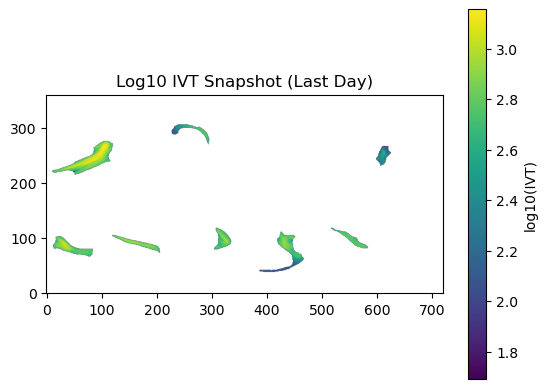

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Define the year of interest
year = '1996'

# Construct the OPeNDAP URL for the dataset
opendap_url = f"https://ar.pik-potsdam.de/thredds/dodsC/eulerian_era5/PIKARTV1_eulerian_ERA5_0p5deg_6hr_{year}.nc"

# Open the dataset directly with xarray
ds = xr.open_dataset(opendap_url)

# Show all variables available in the dataset
print(ds.data_vars)

# Extract the IVT (Integrated Vapor Transport) variable from the dataset
ivt = ds['ivt']

# Display the shape of the IVT array
print(ivt.shape)

# Show IVT snapshot of the last day in dataset
ivt_last = ivt.isel(time=-1)  # Select the last time slice

# Mask all non-positive values as NaN
ivt_snapshot = ivt_last.where(ivt_last > 0, np.nan)

# Plot the log10 of the IVT snapshot to enhance contrast
plt.imshow(np.log10(ivt_snapshot), origin='lower')
plt.title('Log10 IVT Snapshot (Last Day)')
plt.colorbar(label='log10(IVT)')
plt.show()

---

## Summary
Add one final `---` marking the end of your body of content, and then conclude with a brief single paragraph summarizing at a high level the key pieces that were learned and how they tied to your objectives. Look to reiterate what the most important takeaways were.

### What's next?
Let Jupyter book tie this to the next (sequential) piece of content that people could move on to down below and in the sidebar. However, if this page uniquely enables your reader to tackle other nonsequential concepts throughout this book, or even external content, link to it here!